In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from src.getdata_utils import load_data, split_data

In [3]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


In [5]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


Numeric features: ['age', 'day', 'campaign', 'previous', 'was_prev_contacted', 'balance_slog']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Shapes -> Train: (28934, 15), Val: (7234, 15), Test: (9043, 15)
scale_pos_weight ≈ 7.55 (neg/pos)

Stacked Ensemble — Test ROC-AUC: 0.807
Base XGB — Test ROC-AUC: 0.796
Base RF — Test ROC-AUC: 0.796
Base LR — Test ROC-AUC: 0.772

Best Val F1 threshold: 0.167 | F1=0.492, Precision=0.454, Recall=0.538

VALIDATION @ threshold=0.167
Confusion matrix:
 [[5840  548]
 [ 391  455]]
Precision: 0.454  Recall: 0.538  F1: 0.492  ROC-AUC: 0.805

TEST @ threshold=0.167
Confusion matrix:
 [[7398  587]
 [ 521  537]]
Precision: 0.478  Recall: 0.508  F1: 0.492  ROC-AUC: 0.807

Permutation importance (ensemble meta-features) — Validation:
     feature  importance_mean  importance_std
0  proba_XGB         0.013450        0.000911
1   proba_RF         0.007009        0.000446
2   proba_LR         0.

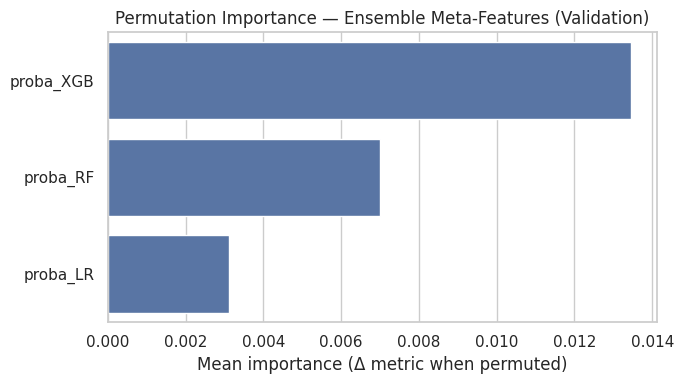


SHAP — Ensemble meta-learner (Validation meta-features)


/tmp/ipykernel_86985/156421358.py:248: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)


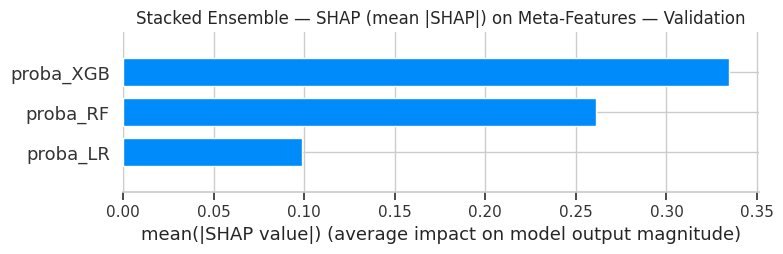

/tmp/ipykernel_86985/156421358.py:252: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, show=False)


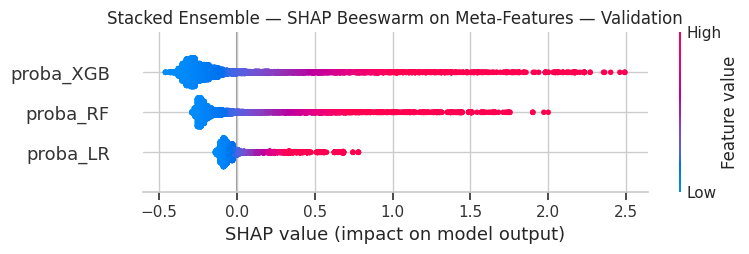


Permutation importance — XGB pipeline (original features) — Validation:
               feature  importance_mean  importance_std
9                month         0.134628        0.003284
8                  day         0.070597        0.000964
7              contact         0.055778        0.002704
12            poutcome         0.020528        0.001178
5              housing         0.011073        0.002376
11            previous         0.007575        0.001043
0                  age         0.007534        0.002091
10            campaign         0.004451        0.001333
13  was_prev_contacted         0.001175        0.000285
4              default         0.000097        0.000322
2              marital        -0.000014        0.001026
6                 loan        -0.000912        0.001207
1                  job        -0.001714        0.001189
3            education        -0.002447        0.000896
14        balance_slog        -0.003138        0.001875


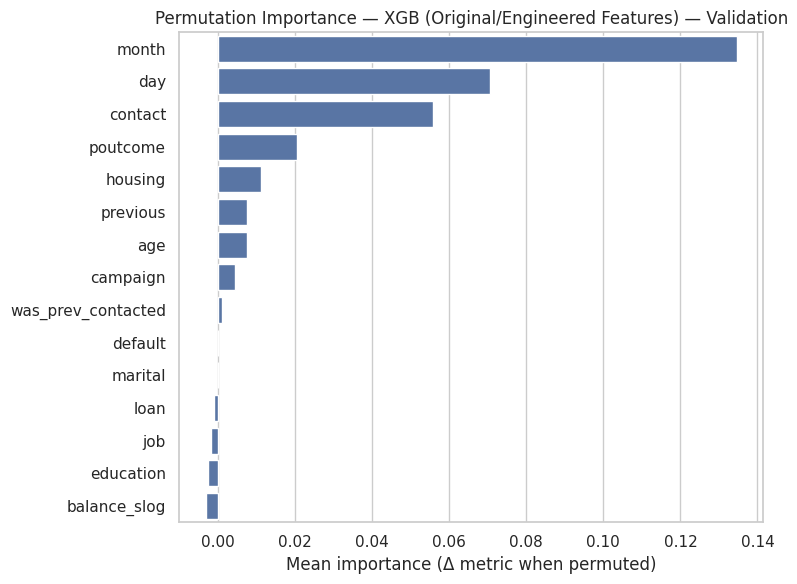


SHAP — XGB base model (Validation features)


/tmp/ipykernel_86985/156421358.py:304: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, show=False)


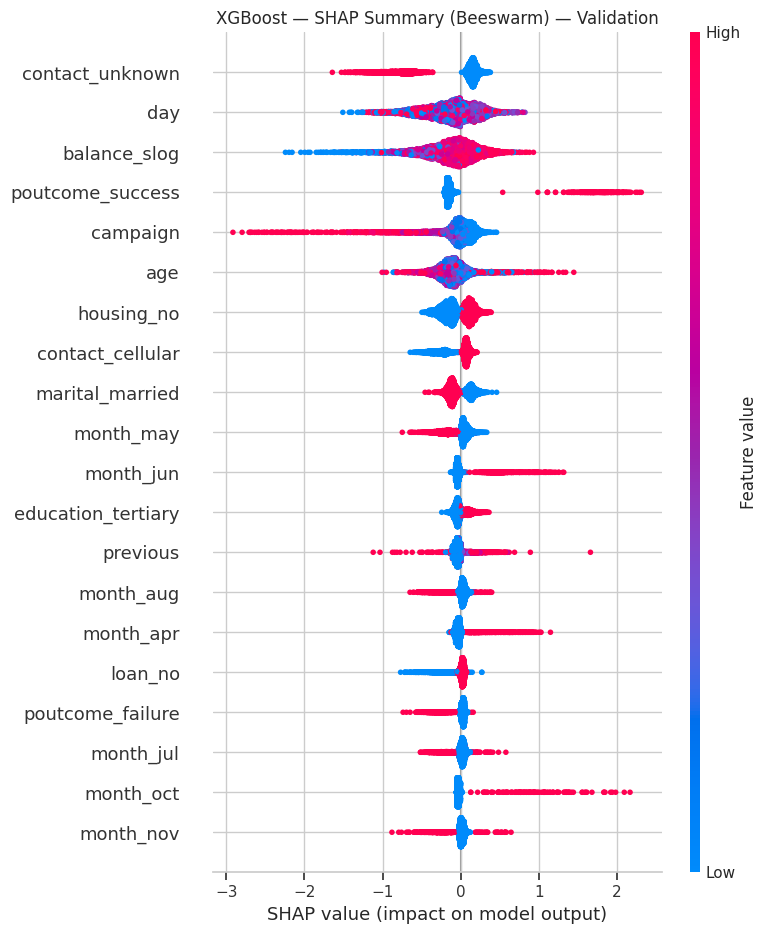

/tmp/ipykernel_86985/156421358.py:309: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, plot_type="bar", show=False)


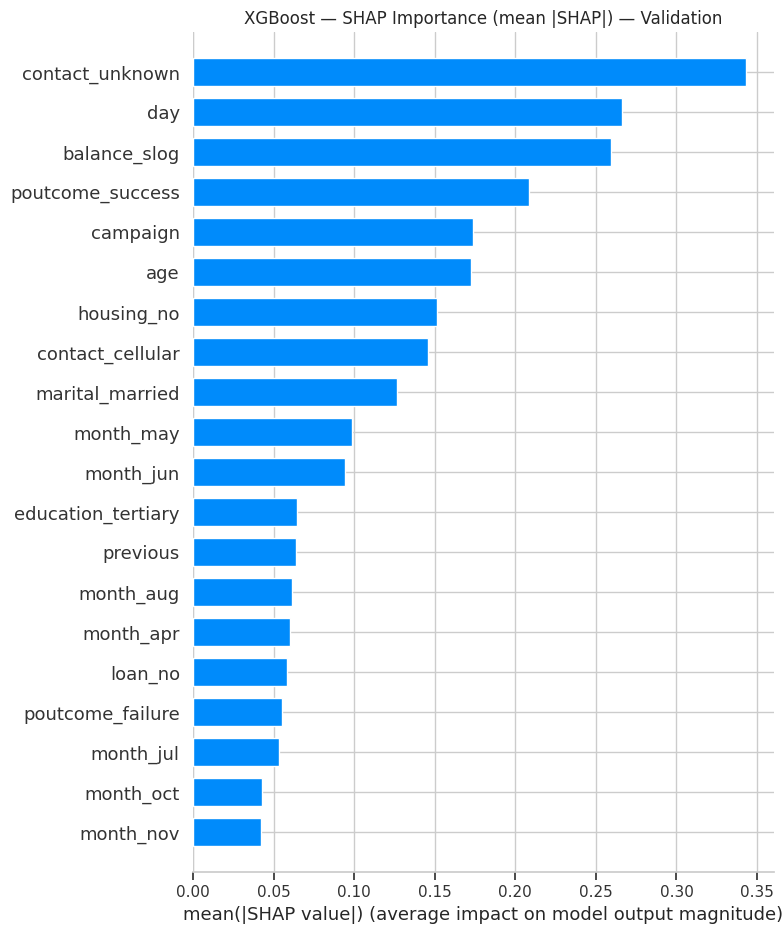


XGBoost — SHAP Importance Aggregated by Original Feature (Validation):
          feature_orig  mean_abs_shap
11               month       0.603671
3              contact       0.512263
12            poutcome       0.274443
4                  day       0.266141
1         balance_slog       0.259135
8                  job       0.196895
7              housing       0.175587
2             campaign       0.173791
0                  age       0.172598
10             marital       0.172358
6            education       0.124366
13            previous       0.063676
9                 loan       0.062004
14  was_prev_contacted       0.007567
5              default       0.005396


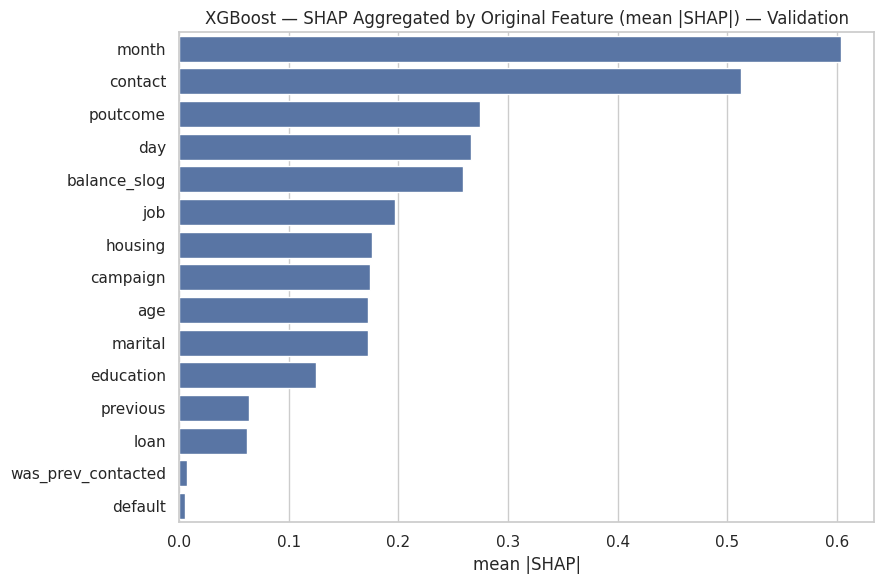

In [15]:
# ==========================================
# 0) Imports
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, precision_recall_fscore_support,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
import shap  # pip install shap ipywidgets

sns.set_theme(style="whitegrid")
np.random.seed(42)

# ==========================================
# 1) Preprocessing and Feature Engineering
# ==========================================
df2 = df.copy()

# Remove duration (leakage)
if "duration" in df2.columns:
    df2 = df2.drop(columns=["duration"])

# Create was_prev_contacted from pdays; drop pdays
if "pdays" in df2.columns:
    df2["was_prev_contacted"] = (df2["pdays"] != -1).astype(int)
    df2 = df2.drop(columns=["pdays"])

# Signed log of balance; drop raw balance
if "balance" in df2.columns:
    df2["balance_slog"] = np.sign(df2["balance"]) * np.log1p(np.abs(df2["balance"]))
    df2 = df2.drop(columns=["balance"])

# Encode target
df2["y_binary"] = df2["y"].map({"no": 0, "yes": 1}).astype(int)

X = df2.drop(columns=["y", "y_binary"])
y = df2["y_binary"]

# Identify numeric vs categorical
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

# ==========================================
# 2) Train / Val / Test split
# ==========================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)

print(f"Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# class imbalance ratio for XGB
neg, pos = np.bincount(y_trainval)
scale_pos_weight = neg / pos
print(f"scale_pos_weight ≈ {scale_pos_weight:.2f} (neg/pos)")

# ==========================================
# 3) Preprocessor
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

# ==========================================
# 4) Base model builders (uncalibrated)
# ==========================================
def make_xgb():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
            tree_method="hist",
            scale_pos_weight=scale_pos_weight
        )),
    ])

def make_rf():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )),
    ])

def make_lr():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
            C=1.0,
            n_jobs=-1,
            random_state=42
        )),
    ])

base_builders = {"xgb": make_xgb, "rf": make_rf, "lr": make_lr}

# ==========================================
# 5) Stacking (OOF meta-features) with calibrated bases (isotonic)
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_meta = pd.DataFrame(index=y_trainval.index, columns=base_builders.keys(), dtype=float)
oof_meta[:] = np.nan

test_meta_parts = {name: np.zeros(len(X_test), dtype=float) for name in base_builders.keys()}

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    X_tr, X_va = X_trainval.iloc[tr_idx], X_trainval.iloc[va_idx]
    y_tr, y_va = y_trainval.iloc[tr_idx], y_trainval.iloc[va_idx]

    for name, builder in base_builders.items():
        base_pipe = builder()
        calib = CalibratedClassifierCV(
            estimator=base_pipe,
            method="isotonic",
            cv=3
        )
        calib.fit(X_tr, y_tr)

        proba_va = calib.predict_proba(X_va)[:, 1]
        oof_meta.loc[y_trainval.iloc[va_idx].index, name] = proba_va

        proba_test = calib.predict_proba(X_test)[:, 1]
        test_meta_parts[name] += proba_test / skf.n_splits

assert not oof_meta.isna().any().any(), "OOF meta-features contain NaNs."

# Meta-learner (keep LR as your chosen stacker)
meta_clf = LogisticRegression(solver="lbfgs", max_iter=2000, C=1.0, n_jobs=-1, random_state=42)
meta_clf.fit(oof_meta.values, y_trainval.values)

# Build TEST meta matrix from averaged base predictions
test_meta = np.column_stack([test_meta_parts[name] for name in base_builders.keys()])

# Ensemble performance on TEST
test_meta_proba = meta_clf.predict_proba(test_meta)[:, 1]
ensemble_auc = roc_auc_score(y_test, test_meta_proba)
print(f"\nStacked Ensemble — Test ROC-AUC: {ensemble_auc:.3f}")

# Base model TEST AUCs (calibrated on full Train+Val)
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_full = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_full.fit(X_trainval, y_trainval)
    proba = calib_full.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"Base {name.upper()} — Test ROC-AUC: {auc:.3f}")

# ==========================================
# 6) Threshold tuning on VALIDATION (maximize F1 by default)
# ==========================================
val_meta_feats, meta_feature_names = [], []
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_train = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_train.fit(X_train, y_train)
    proba_val = calib_train.predict_proba(X_val)[:, 1]
    val_meta_feats.append(proba_val)
    meta_feature_names.append(f"proba_{name.upper()}")

val_meta = np.column_stack(val_meta_feats)
val_meta_proba = meta_clf.predict_proba(val_meta)[:, 1]

prec, rec, thr = precision_recall_curve(y_val, val_meta_proba)
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
best_idx = np.nanargmax(f1s)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
print(f"\nBest Val F1 threshold: {best_thr:.3f} | F1={f1s[best_idx]:.3f}, "
      f"Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}")

def print_metrics(split, y_true, y_prob, thr):
    y_hat = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary")
    print(f"\n{split} @ threshold={thr:.3f}")
    print("Confusion matrix:\n", cm)
    print(f"Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}  ROC-AUC: {roc_auc_score(y_true, y_prob):.3f}")

print_metrics("VALIDATION", y_val, val_meta_proba, best_thr)
print_metrics("TEST", y_test, test_meta_proba, best_thr)

# ==========================================
# 7) PERMUTATION IMPORTANCE — Ensemble (meta-features) on VALIDATION
# ==========================================
print("\nPermutation importance (ensemble meta-features) — Validation:")
perm_meta = permutation_importance(
    meta_clf, val_meta, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_meta_df = pd.DataFrame({
    "feature": meta_feature_names,
    "importance_mean": perm_meta.importances_mean,
    "importance_std": perm_meta.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_meta_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=perm_meta_df, x="importance_mean", y="feature")
plt.title("Permutation Importance — Ensemble Meta-Features (Validation)")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 8) SHAP — Ensemble meta-learner (on meta-features)
# ==========================================
print("\nSHAP — Ensemble meta-learner (Validation meta-features)")
try:
    explainer_meta = shap.LinearExplainer(meta_clf, val_meta)
    shap_vals_meta = explainer_meta.shap_values(val_meta)
    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)
    plt.title("Stacked Ensemble — SHAP (mean |SHAP|) on Meta-Features — Validation")
    plt.tight_layout(); plt.show()

    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, show=False)
    plt.title("Stacked Ensemble — SHAP Beeswarm on Meta-Features — Validation")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("LinearExplainer fallback -> KernelExplainer due to:", e)
    background = val_meta[:200]
    explainer_meta = shap.KernelExplainer(meta_clf.predict_proba, background)
    shap_vals_meta = explainer_meta.shap_values(val_meta, nsamples=200)
    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)
    plt.title("Stacked Ensemble — SHAP (mean |SHAP|) on Meta-Features — Validation")
    plt.tight_layout(); plt.show()

# ==========================================
# 9) PERMUTATION IMPORTANCE — XGB (original features) on VALIDATION
#    (model-agnostic, importance per original/engineered column)
# ==========================================
print("\nPermutation importance — XGB pipeline (original features) — Validation:")
xgb_pipe_uncal = make_xgb().fit(X_train, y_train)  # uncalibrated for speed/clarity
perm_xgb = permutation_importance(
    xgb_pipe_uncal, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_xgb_df = pd.DataFrame({
    "feature": X.columns.tolist(),
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_xgb_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_xgb_df.head(20), x="importance_mean", y="feature")
plt.title("Permutation Importance — XGB (Original/Engineered Features) — Validation")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 10) SHAP — XGB base model on Validation (feature-level)
# ==========================================
print("\nSHAP — XGB base model (Validation features)")
# Transform X_val and get transformed feature names
pre = xgb_pipe_uncal.named_steps["preprocess"]
X_val_trans = pre.transform(X_val)
ohe = pre.named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_features)
feat_names_trans = list(num_features) + list(ohe_names)

# TreeExplainer on XGB
explainer_xgb = shap.TreeExplainer(xgb_pipe_uncal.named_steps["clf"])
shap_vals_val = explainer_xgb.shap_values(X_val_trans)

# Beeswarm (direction + impact)
shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, show=False)
plt.title("XGBoost — SHAP Summary (Beeswarm) — Validation")
plt.tight_layout(); plt.show()

# Bar (global importance)
shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, plot_type="bar", show=False)
plt.title("XGBoost — SHAP Importance (mean |SHAP|) — Validation")
plt.tight_layout(); plt.show()

# Aggregate SHAP back to ORIGINAL columns (sum |SHAP| across one-hot levels)
mean_abs_shap = np.mean(np.abs(shap_vals_val), axis=0)
shap_df = pd.DataFrame({"feature_trans": feat_names_trans, "mean_abs_shap": mean_abs_shap})

def parent_name(trans_name: str) -> str:
    if trans_name in num_features:
        return trans_name
    return trans_name.split("_", 1)[0]

shap_df["feature_orig"] = shap_df["feature_trans"].apply(parent_name)
shap_agg = (shap_df.groupby("feature_orig", as_index=False)["mean_abs_shap"]
                  .sum()
                  .sort_values("mean_abs_shap", ascending=False))
print("\nXGBoost — SHAP Importance Aggregated by Original Feature (Validation):")
print(shap_agg.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=shap_agg.head(20), x="mean_abs_shap", y="feature_orig")
plt.title("XGBoost — SHAP Aggregated by Original Feature (mean |SHAP|) — Validation")
plt.xlabel("mean |SHAP|"); plt.ylabel("")
plt.tight_layout(); plt.show()


BEESWARM:
X-axis = SHAP value (impact on model output):
Negative → pushes prediction toward NO subscription
Positive → pushes prediction toward YES subscription

Color = feature value:
Blue = low value, Red = high value

1. Age

Blue (younger) → slightly positive SHAP (higher chance to subscribe).

Red (older) → mostly negative SHAP (lower chance).
➡ Younger clients are more likely to subscribe, older clients less likely.

2. Housing_no (binary: yes/no housing loan)

Red = “no housing loan”. These tend to be slightly positive (increasing subscription).

Blue = “yes housing loan”. These cluster left (negative).
➡ Clients without a housing loan are more likely to subscribe. Those with housing loans are less likely.

3. Contact_cellular

Red = “contacted by cellular”. Strongly pushes positive.

Blue = “not cellular” (landline/other). Mostly neutral/negative.
➡ Cellular contact is one of the biggest drivers of successful subscription.


4. Marital_married

Red = “married”. Mostly clustered negative.

Blue = “not married” (single/divorced). Slightly more positive.
➡ Married clients are less likely to subscribe compared to single/divorced.

5. Month_may

Red = contacted in May. Strongly negative.
➡ May was a campaign-heavy month, with many recontacts and lower success — pushes toward “no”.

6. Month_jun

Red = contacted in June. More balanced, but some positive SHAP values.
➡ June contacts perform better than May, but not strongly positive overall.

7. Education_tertiary

Red = “tertiary education”. Spread across both sides, but a tilt toward positive.
➡ Higher-educated clients are somewhat more likely to subscribe.

8. Previous (# of contacts in past campaigns)

Blue = few/no previous contacts → some positive.

Red = many previous contacts → mostly negative.
➡ The more times a client was contacted before, the less likely they are to subscribe now (over-contact fatigue).

9. Month_aug

Red = contacted in August. Mixed impact, but a tilt toward positive.
➡ August campaigns had some success, but effect is smaller than other months.

10. Month_apr

Red = contacted in April. Mostly positive.
➡ April appears to be a good campaign month (higher subscription likelihood).

11. Loan_no

Red = “no personal loan”. Slightly positive.

Blue = “has a loan”. More negative.
➡ Clients without personal loans are more likely to subscribe.

takeaways:

Best positive signals: Cellular contact, no housing/loan, tertiary education, April/October campaigns, younger age.

Strong negatives: Contact=unknown (not visible here), May campaigns, previous failures, older clients, being married.